implementation of K means clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# loading dataset
df=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\customer-segmentation-system\data\Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


ask 3 — Select Features for Clustering

K-Means works with numerical features.

Best features for this dataset:

Annual Income
Spending Score

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

Task 4 — Feature Scaling

K-Means is distance-based, so scaling is important.

In [4]:
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Load PCA
import pickle

pca = pickle.load(open("../models/pca.pkl", "rb"))

# Transform data
X_pca = pca.transform(X_scaled)

Task 5 — Implement the Elbow Method

Goal:

Find optimal number of clusters (K)

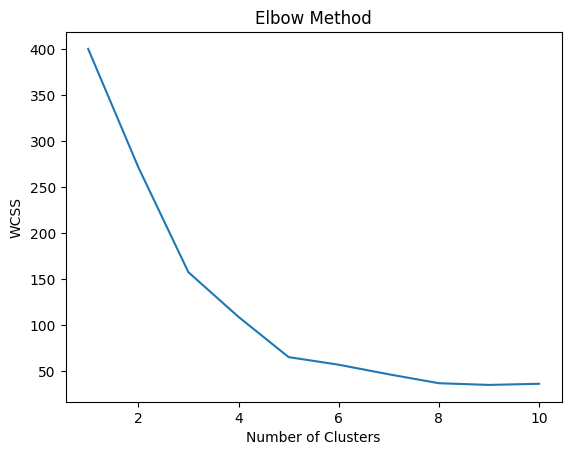

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    # kmeans.fit(X_scaled)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

the elbow point is k=5

Task 6 — Train the K-Means Model

Now use the optimal K.

In [6]:
# kmeans = KMeans(n_clusters=5)
# clusters = kmeans.fit_predict(X_scaled)

# Apply KMeans on PCA data
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_pca)

labels = kmeans.labels_

In [7]:
# adding clusters to the dataset
df['Cluster'] = labels

Task 7 — Visualize the Clusters

Visualization is very important for projects.

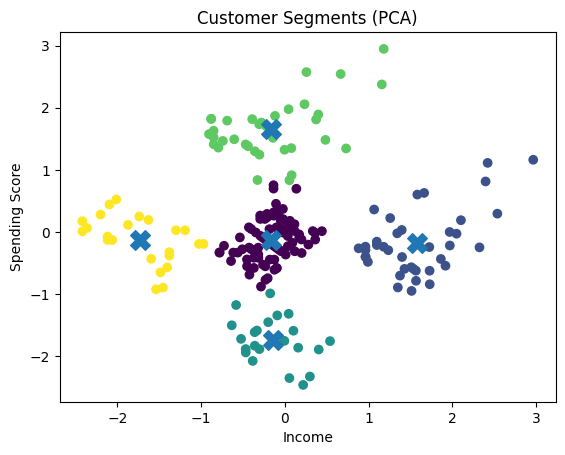

In [8]:
import matplotlib.pyplot as plt
# plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            marker='X')

plt.title("Customer Segments (PCA)")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

Result:

Each color = customer group

X = centroid

Task 8 — Analyze the Clusters

Now interpret clusters.

Analysis:
Cluster	    Meaning
0	        Low income low spending
1	        High income high spending
2	        Average customers
3	        High income low spending
4	        Low income high spending

Business insight:

Cluster 1 → Premium customers
Cluster 4 → Potential targets
Cluster 0 → Budget customers

This is real business analysis.

Task 9 — Save the Model
save the trained model.

In [9]:
import joblib

joblib.dump(kmeans, "../models/kmeans_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']